In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from tabulate import tabulate
from SQUIC_functions import *
from scipy import sparse

from collections import defaultdict
from scipy.sparse import coo_matrix, lil_matrix

In [2]:
# def create_dataframe_and_matrix(csv_file_path, max_steps=365):
#     # First pass: identify unique users and fraud accounts
#     print("First pass: Identifying users and fraud accounts...")
#     unique_users = set()
#     fraud_accounts = set()
    
#     chunk_size = 100000
#     for chunk in pd.read_csv(csv_file_path, chunksize=chunk_size):
#         # Get unique users
#         orig_users = chunk['nameOrig'].dropna().unique()
#         dest_users = chunk['nameDest'].dropna().unique()
#         unique_users.update(orig_users)
#         unique_users.update(dest_users)
        
#         # Identify fraud accounts
#         fraud_rows = chunk[chunk['isFraud'] == 1]
#         fraud_accounts.update(fraud_rows['nameOrig'].dropna())
#         fraud_accounts.update(fraud_rows['nameDest'].dropna())
        
#         del chunk
    
#     unique_users = sorted(list(unique_users))
#     print(f"Found {len(unique_users)} unique users")
#     print(f"Found {len(fraud_accounts)} fraud accounts")
    
#     # Create user-to-id mapping
#     user_to_id = {user: i for i, user in enumerate(unique_users)}
#     max_account_id = len(unique_users)
    
#     # Initialize DataFrame for balances
#     df = pd.DataFrame(index=range(max_steps), columns=unique_users, dtype=float)
    
#     # Initialize transaction tracking
#     edge_weights = defaultdict(float)
    
#     # Track which users we've seen for balance tracking
#     user_first_seen = {}
    
#     print("Second pass: Processing transactions and building matrices...")
    
#     # Second pass: populate DataFrame and build transaction matrix
#     for chunk in pd.read_csv(csv_file_path, chunksize=chunk_size):
#         for _, row in chunk.iterrows():
#             step = int(row['step'])
#             amount = float(row['amount'])
            
#             # Get users
#             orig_user = row['nameOrig']
#             dest_user = row['nameDest']
            
#             # Build transaction matrix (only if both users are valid)
#             if orig_user in user_to_id and dest_user in user_to_id:
#                 i = user_to_id[orig_user]
#                 j = user_to_id[dest_user]
#                 edge_weights[(i, j)] += amount
            
#             # Process origin user for balance DataFrame
#             old_balance = float(row['oldBalanceOrig'])
#             new_balance = float(row['newBalanceOrig'])
                
#             if orig_user not in user_first_seen:
#                 # First time seeing this user - backfill with old balance
#                 if step > 0:
#                     df.loc[:step-1, orig_user] = old_balance
#                 user_first_seen[orig_user] = True
                
#             # Update from current step onwards
#             df.loc[step:, orig_user] = new_balance
            
#             # Process destination user for balance DataFrame
#             old_balance = float(row['oldBalanceDest'])
#             new_balance = float(row['newBalanceDest'])
                
#             if dest_user not in user_first_seen:
#                 # First time seeing this user - backfill with old balance
#                 if step > 0:
#                     df.loc[:step-1, dest_user] = old_balance
#                 user_first_seen[dest_user] = True
                
#             # Update from current step onwards
#             df.loc[step:, dest_user] = new_balance
        
#         del chunk
    
#     # Convert edge_weights dict to sparse matrix
#     print("Converting transaction data to sparse matrix...")
#     rows, cols, data = zip(*[(i, j, amt) for (i, j), amt in edge_weights.items()])
#     transaction_matrix = coo_matrix((data, (rows, cols)), 
#                                       shape=(max_account_id, max_account_id)).tolil()
   
#     # Create account properties dictionary
#     account_prop = {
#         i: {
#             "original_id": user,
#             "fraud": user in fraud_accounts,
#             "class": str(user)[0]  # 'C', 'M', or 'B'
#         }
#         for i, user in enumerate(unique_users)
#     }
    
#     print(f"Balance DataFrame shape: {df.shape}")
#     print(f"Transaction matrix shape: {transaction_matrix.shape}")
#     print(f"Transaction matrix nnz (non-zero elements): {transaction_matrix.nnz}")
    
#     return df, account_prop, transaction_matrix

In [3]:
# df, account_prop, transaction_matrix = create_dataframe_and_matrix("rawLog.csv", max_steps=365)

In [4]:
# # Plot the balance evolution for all users (columns) as separate lines
# # plt.figure(figsize=(15,10), dpi= 300)
# plt.figure(figsize=(15,10))

# # Plot each column (account balance) as a line
# for user in df.columns:
#     if user.startswith('C'):
#         color = 'mediumseagreen'
#     elif user.startswith('B'):
#         color = 'crimson'
#     else:
#         color = 'darkturquoise'
#     plt.plot(df.index, df[user], color=color, label=f"User {user}", alpha=0.6)

# # Add title and labels
# plt.xlabel("Days", fontsize=22)
# plt.ylabel("Balance", fontsize=22)

# # Rotate x-axis labels for better visibility
# plt.tick_params(axis='x', labelsize=22)
# plt.tick_params(axis='y', labelsize=22)

# # Display the plot
# plt.tight_layout()
# plt.show()

In [5]:
chunk = pd.read_csv('1Mpaysim.csv', chunksize=100000)

df = pd.concat(chunk)

In [6]:
transaction_matrix = sparse.load_npz('matrice_sparsa.npz')

In [7]:
# Y = df.T.values

In [8]:
df

,0,1,2,3,4,5,6,7,8,9,...,355,356,357,358,359,360,361,362,363,364
0,0.00,38748022.96,44500109.82,44805942.64,44805942.64,44805942.64,54457273.84,1.322618e+08,4.467203e+08,9.503598e+08,...,3.529271e+10,3.569473e+10,3.590629e+10,3.606301e+10,3.624027e+10,3.628493e+10,3.629402e+10,3.629501e+10,3.629501e+10,3.629501e+10
1,46136.85,46136.85,46136.85,46136.85,46136.85,46136.85,46136.85,5.091310e+04,5.091310e+04,1.940439e+05,...,3.724205e+06,3.708669e+06,3.738147e+06,3.972785e+06,4.363832e+06,4.362466e+06,4.362466e+06,4.362466e+06,4.362466e+06,4.362466e+06
2,4.01,4.01,4.01,4.01,4.01,4.01,4.01,4.010000e+00,2.618574e+04,2.240807e+05,...,3.434386e+06,3.359851e+06,2.532494e+06,2.864600e+06,2.769015e+06,2.769015e+06,2.769015e+06,2.769015e+06,2.769015e+06,2.769015e+06
3,13.83,13.83,13.83,13.83,13.83,13.83,13.83,1.383000e+01,1.901864e+05,4.443388e+05,...,6.210840e+06,6.210840e+06,6.210840e+06,6.201010e+06,6.201010e+06,6.201010e+06,6.201010e+06,6.201010e+06,6.201010e+06,6.201010e+06
4,21.50,21.50,21.50,21.50,21.50,21.50,21.50,2.150000e+01,1.851015e+05,1.851015e+05,...,2.541946e+06,2.541946e+06,2.720207e+06,2.720207e+06,2.720207e+06,2.720207e+06,2.720207e+06,2.720207e+06,2.720207e+06,2.720207e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1021796,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.000000e+00,-7.300088e+05,-1.548277e+06,...,-1.186394e+07,6.762475e+05,-1.236684e+07,-1.236684e+07,6.994323e+05,-1.243337e+07,-1.243337e+07,-1.243337e+07,-1.243337e+07,-1.243337e+07
1021797,0.00,-388387.69,-388387.69,-388387.69,-388387.69,-388387.69,-388387.69,-3.883877e+05,-7.652030e+05,-1.352554e+06,...,-1.189218e+07,-1.196100e+07,-1.232469e+07,-1.212556e+07,-1.228358e+07,-1.222541e+07,-1.222541e+07,-1.222541e+07,-1.222541e+07,-1.222541e+07
1021798,0.00,-22334.81,-22334.81,-139917.52,-139917.52,-139917.52,-139917.52,-2.146332e+05,-1.172099e+06,-1.619977e+06,...,7.839177e+05,-8.136800e+06,-8.678984e+06,-8.539578e+06,8.409687e+05,8.409687e+05,8.409687e+05,8.409687e+05,8.409687e+05,8.409687e+05
1021799,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-3.689773e+05,-9.396523e+05,-1.172582e+06,...,8.595140e+05,8.949103e+05,9.151657e+05,-9.906638e+06,-9.906638e+06,-9.906638e+06,-9.906638e+06,-9.906638e+06,-9.906638e+06,-9.906638e+06


In [9]:
Y = df.values

In [10]:
# Compute std dev per row
row_std = np.std(Y, axis=1, keepdims=True)

# Avoid division by zero
row_std[row_std == 0] = 1.0

# Normalize each row
Y_new = Y / row_std

In [11]:
print("NaNs?", np.isnan(Y_new).any())
print("Infs?", np.isinf(Y_new).any())
print("Max:", np.max(Y_new))
print("Min:", np.min(Y_new))
print("Mean std per row (should be 1):", round(np.mean(np.std(Y_new, axis=1)), 2))

NaNs? False
Infs? False
Max: 19.131198270175027
Min: -4.729643441613517
Mean std per row (should be 1): 0.99


In [12]:
l = [0.9989, 0.9988, 0.9985, 0.998]

In [13]:
Theta_dict = {}

In [14]:
ROWS = Y_new.shape[0]
ROWS

1021801

In [15]:
# data_nnz = []
# data_nnzr = []
# data_time = []
# data_sym = []

# for rho in l:
#     Theta, _, computation_time = compute_squic(Y_new, rho)
#     computation_time = round(computation_time, 2)
#     print(f"time required: {computation_time} seconds")

#     Theta = sparse.csr_matrix(Theta) # store Theta as sparse
#     Theta_dict[rho] = Theta

#     nonz, nonz_r = nnz_sparse(Theta_dict[rho], ROWS)

#     print("Checking if symmetric")
#     if check_symmetric_sparse(Theta_dict[rho]):
#         print(f"✅ Matrix is symmetric per rho {rho}")
#         data_sym.append('Yes')
#     else:
#         print(f"❌ Matrix is not symmetric per rho {rho}")
#         data_sym.append('No')

#     data_nnz.append(nonz)
#     data_nnzr.append(nonz_r)
#     data_time.append(computation_time)

#     if nonz == ROWS:
#         print(f"For rho = {rho} just element on the diagonal")
#         print_matrix(Theta_dict[rho])
#     elif nonz == ROWS * ROWS:
#         print(f"For rho = {rho} big dense matrix")
#         print(f"nnz = {nonz}")
#         print(f"nnz/row = {nonz_r}")
#         print_matrix(Theta_dict[rho])
#     else:
#         print(f"For rho = {rho} there are some nnz")
#         print(f"nnz = {nonz}")
#         print(f"nnz/row = {nonz_r}")
#         print_matrix(Theta_dict[rho])


# table_squic_norm = [
#     ["NNZ"] + data_nnz,
#     ["NNZ/Row"] + data_nnzr,
#     ["Time (s)"] + data_time,
#     ["Symmetric"] + data_sym
# ]

# SQUIC-Fit

In [21]:
l = [0.997, 0.996, 0.995]


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.093177e+02
 Y:         1021801 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.970000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=4.97e+00 time=1.03e+03
* iter=1 time=5.04e+00 obj=1.82e+06 |delta(obj)|/obj=4.43e-01 nnz(X,L,W)/p=[4.97e+00 3.41e+00 1.00e+00] lns_iter=3 
* iter=2 time=1.08e+01 obj=1.80e+06 |delta(obj)|/obj=8.47e-03 nnz(X,L,W)/p=[4.97e+00 3.41e+00 2.03e+00] lns_iter=5 
* iter=3 time=1.34e+02 obj=1.78e+06

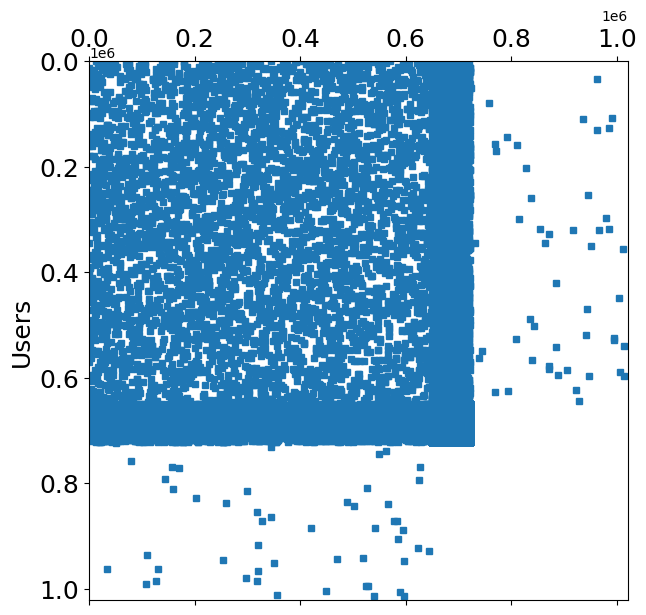

✅ Matrix is symmetric per rho 0.997

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.093177e+02
 Y:         1021801 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.960000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=5.51e+00 time=1.03e+03
* iter=1 time=6.03e+00 obj=1.91e+06 |delta(obj)|/obj=4.71e-01 nnz(X,L,W)/p=[5.51e+00 7.23e+00 1.00e+00] lns_iter=4 
* iter=2 time=1.09e+01 obj=1.85e+06 |delta(obj)|/obj=3.57e-02 nnz(X,L,W)/p=[5.51e+00 7.23e+00 1.55e+00] lns_iter=4 

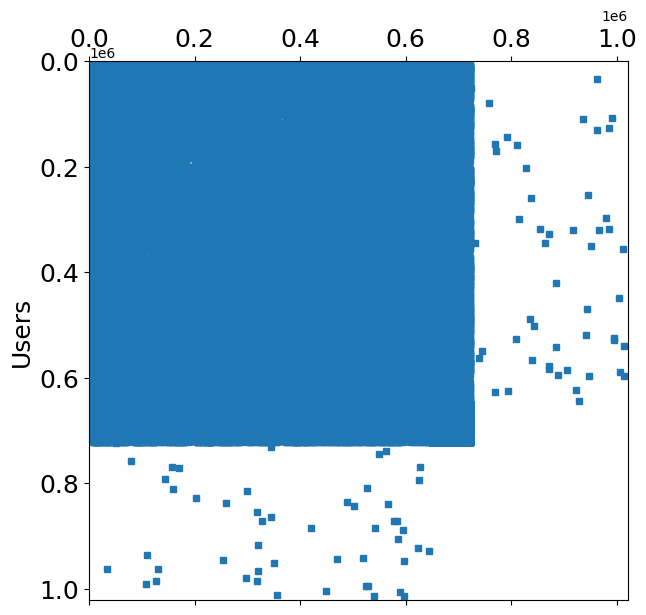

✅ Matrix is symmetric per rho 0.996

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.093177e+02
 Y:         1021801 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.950000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 


In [ ]:
W_dict = {}

data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    W, end_time = squic_fit_matrix_sparse(Y_new, l=rho, matrix=transaction_matrix)
    W_dict[rho] = sparse.csr_matrix(W)
    end_time = round(end_time, 2)
    print(f"required time: {end_time}")

    nnz, nnz_r = nnz_sparse(W_dict[rho], ROWS)
    print(f"nnz = {nnz} per rows = {nnz_r}")

    print_matrix(W_dict[rho])

    if check_symmetric_sparse(W_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append("Yes")
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append("No")

    data_nnz.append(nnz)
    data_nnzr.append(nnz_r)
    data_time.append(end_time)

table_fit_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]


In [17]:
from tabulate import tabulate

In [18]:
def table(data, title, l):
    table = tabulate(
        data,
        headers=[title] + l,
        tablefmt="fancy_grid",
        numalign="center",
        stralign="center"
    )
    return table

In [20]:
# print(table(table_squic_norm, "SQUIC NORM", l))

print(table(table_fit_norm, "SQUIC FIT NORM", l))

╒══════════════════╤══════════╤══════════╤══════════╤═════════╕
│  SQUIC FIT NORM  │  0.9989  │  0.9988  │  0.9985  │  0.998  │
╞══════════════════╪══════════╪══════════╪══════════╪═════════╡
│       NNZ        │ 3329312  │ 3366834  │ 3443418  │ 3631206 │
├──────────────────┼──────────┼──────────┼──────────┼─────────┤
│     NNZ/Row      │   3.26   │   3.29   │   3.37   │  3.55   │
├──────────────────┼──────────┼──────────┼──────────┼─────────┤
│     Time (s)     │ 1349.54  │ 1430.43  │ 1577.73  │ 1694.81 │
├──────────────────┼──────────┼──────────┼──────────┼─────────┤
│    Symmetric     │   Yes    │   Yes    │   Yes    │   Yes   │
╘══════════════════╧══════════╧══════════╧══════════╧═════════╛
